In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Getting started.pdf', 'Sushanthi_GUESS BOARD.pptx', 'FT_Receipt_03-10-2025-21-09-48.pdf', 'Saved from the Google app', 'Google AI Studio', 'video-output-B2E359BC-6D01-409A-B760-882BB56D176B-1.mov', 'Classroom', 'Colab Notebooks', 'dataset_for_colab.zip', 'accident_best.pt', 'RESQ', 'WIN_20260514_07_42_07_Pro.mp4', 'SynapseAI - Project Analysis.gslides', 'cc634461-0a4a-40e3-9833-bdf1499babe3.mp4', 'ORIGINS-PPT Template.pdf.pdf', 'Screenshot 2026-08-13 211257.png', 'Screenshot 2026-08-13 213042.png', 'Screenshot 2026-08-13 213131.png', 'WhatsApp Image 2026-08-13 at 9.32.53 PM.jpeg', 'Baseline Basic Assessment - Schedule-2.xlsx', 'archive (10)']


In [7]:
dataset_path = '/content/drive/MyDrive/archive (10)/PlantVillage'
print(os.listdir(dataset_path))

['Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']


In [8]:
import os
import pandas as pd

# Get the class/folder names
class_names = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [9]:
import os
import pandas as pd
class_counts = []
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    class_counts.append([class_name, count])
df_counts = pd.DataFrame(
    class_counts,
    columns=["Class", "Number of Images"]
)
df_counts

,Class,Number of Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


In [10]:
total_images = df_counts["Number of Images"].sum()
print("Total number of images:", total_images)
print("Number of classes:", len(class_names))

Total number of images: 20639
Number of classes: 15


In [11]:
print("Maximum images in a class:",
      df_counts["Number of Images"].max())
print("Minimum images in a class:",
      df_counts["Number of Images"].min())

Maximum images in a class: 3208
Minimum images in a class: 152


In [12]:
df_counts.sort_values(
    "Number of Images",
    ascending=False
)

,Class,Number of Images
12,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
5,Tomato_Bacterial_spot,2127
7,Tomato_Late_blight,1909
9,Tomato_Septoria_leaf_spot,1771
10,Tomato_Spider_mites_Two_spotted_spider_mite,1677
14,Tomato_healthy,1591
1,Pepper__bell___healthy,1478
11,Tomato__Target_Spot,1404
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000


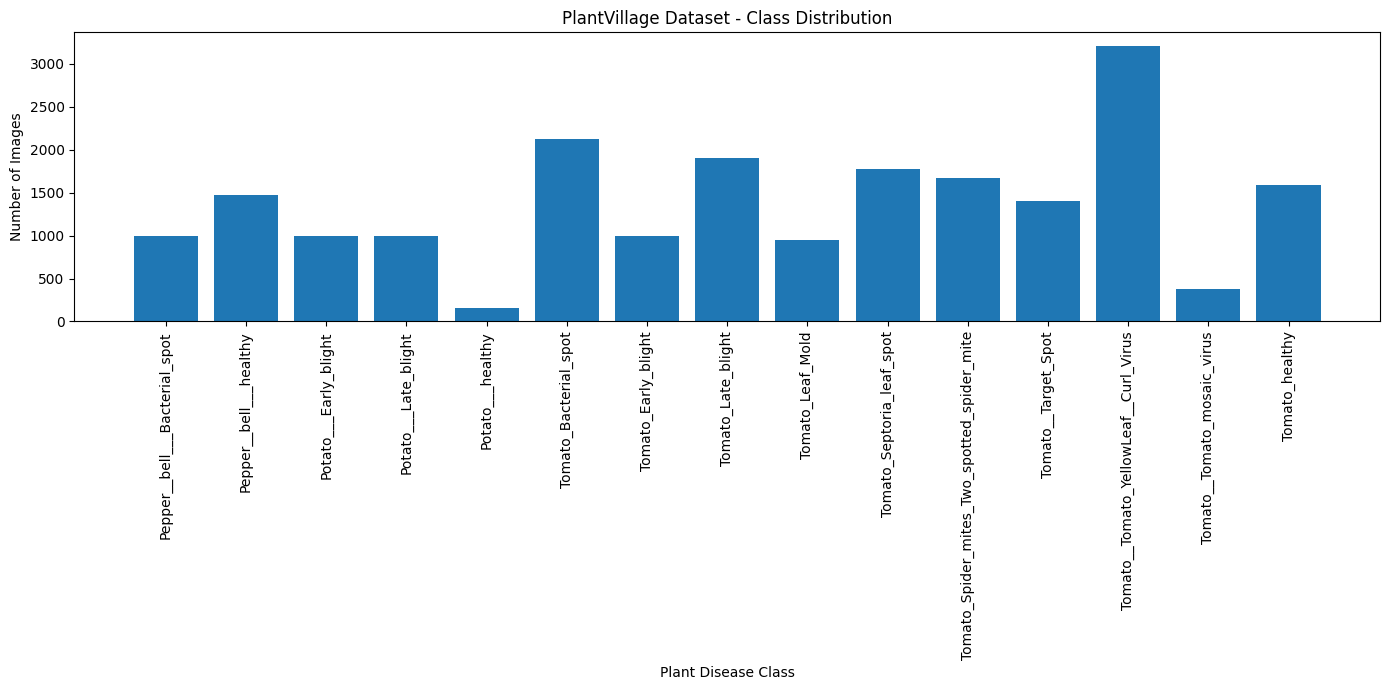

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
plt.bar(
    df_counts["Class"],
    df_counts["Number of Images"]
)
plt.xlabel("Plant Disease Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage Dataset - Class Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

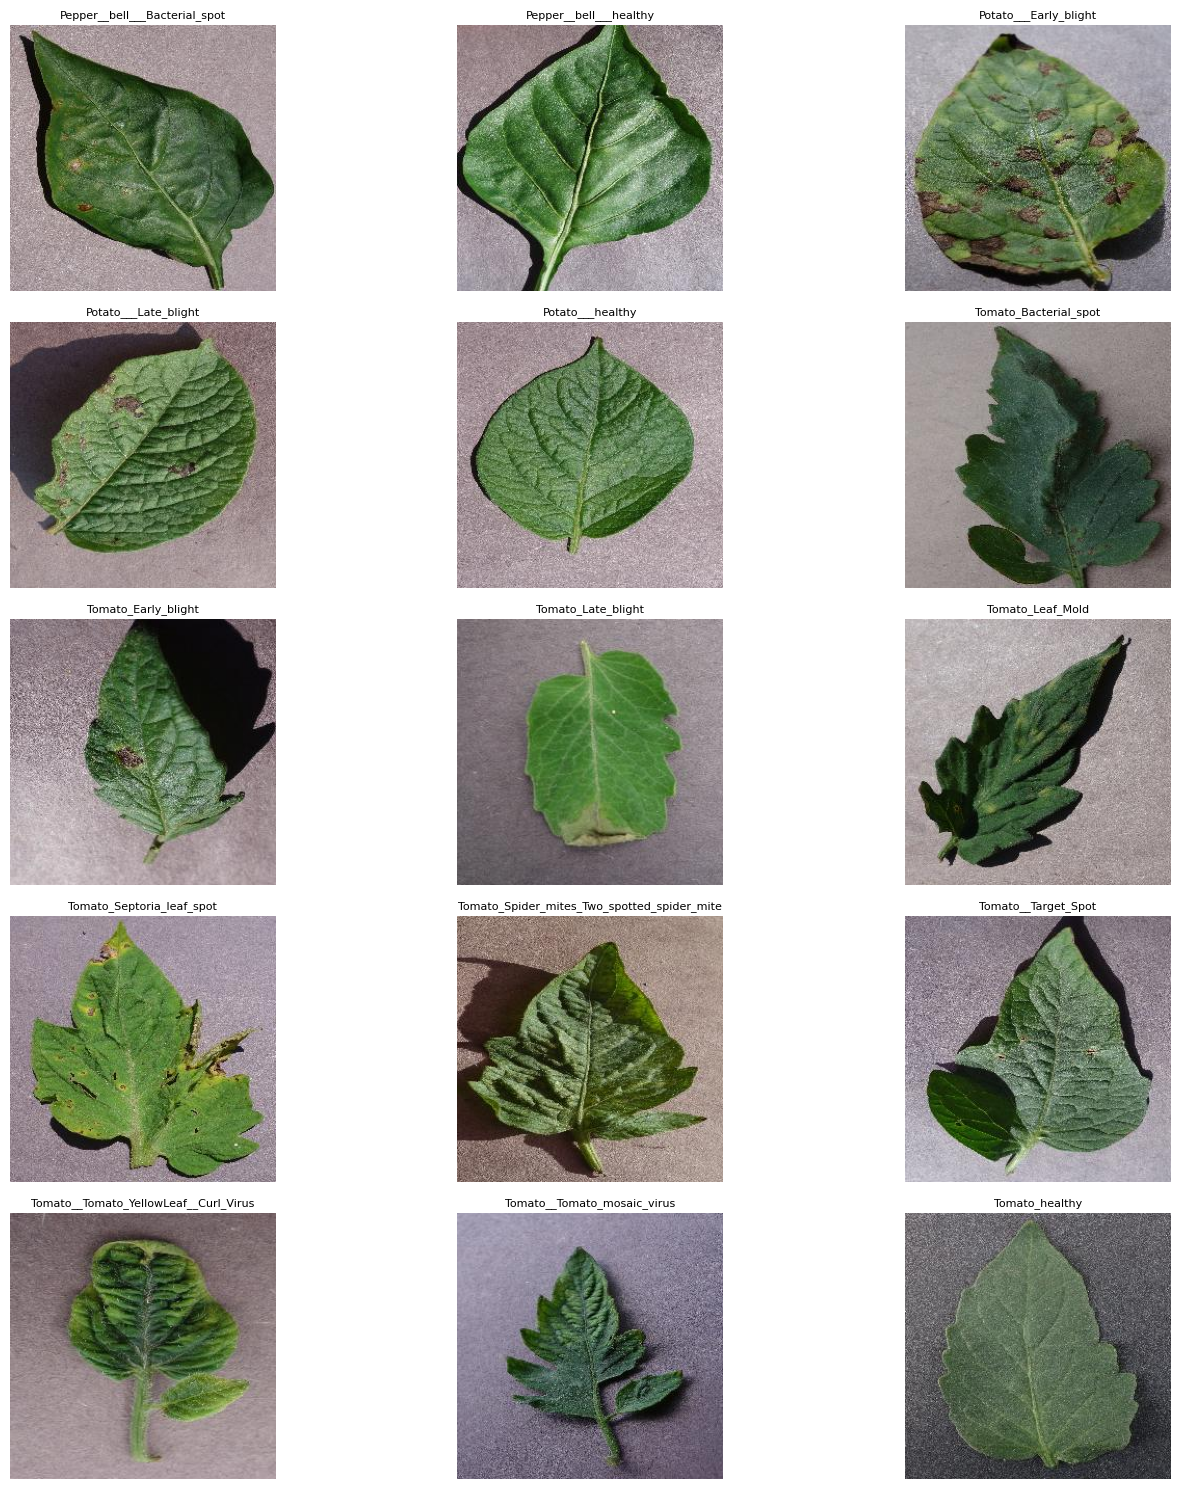

In [14]:
from PIL import Image
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random_image = random.choice(image_files)

    image_path = os.path.join(
        class_path,
        random_image
    )

    image = Image.open(image_path)

    plt.subplot(5, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
image_sizes = []

for class_name in class_names:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # Check first 10 images from each class
    for image_file in image_files[:10]:

        image_path = os.path.join(
            class_path,
            image_file
        )

        with Image.open(image_path) as img:
            image_sizes.append(img.size)

print("First 20 image sizes:")
print(image_sizes[:20])

First 20 image sizes:
[(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


In [16]:
import tensorflow as tf
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 20639 files belonging to 15 classes.
Using 16512 files for training.


In [18]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 20639 files belonging to 15 classes.
Using 4127 files for validation.


In [19]:
images, labels = next(iter(train_ds))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


In [20]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)
val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [22]:
model = tf.keras.Sequential([

    # Data augmentation
    data_augmentation,

    # Normalize pixel values from 0-255 to 0-1
    tf.keras.layers.Rescaling(1./255),

    # CNN Layer 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    # CNN Layer 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    # CNN Layer 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    # Convert feature maps to a single vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Reduce overfitting
    tf.keras.layers.Dropout(0.5),

    # 15 disease classes
    tf.keras.layers.Dense(
        15,
        activation='softmax'
    )
])

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
EPOCHS = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)
model.save(
    "/content/drive/MyDrive/plant_disease_cnn.keras"
)

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 2869s 6s/step - accuracy: 0.3768 - loss: 1.9448 - val_accuracy: 0.5777 - val_loss: 1.3016
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.5830 - loss: 1.2890 - val_accuracy: 0.7097 - val_loss: 0.8822
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.6460 - loss: 1.0519 - val_accuracy: 0.6903 - val_loss: 0.9615
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.6917 - loss: 0.9348 - val_accuracy: 0.7843 - val_loss: 0.6227
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.7155 - loss: 0.8454 - val_accuracy: 0.7921 - val_loss: 0.6304
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 0.7393 - loss: 0.7729 - val_accuracy: 0.7652 - val_loss: 0.7110
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.7651 - loss: 0.6903 - val_accuracy: 0.8490 - val_loss: 0.4206
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.7752 - loss: 0.6684 - 

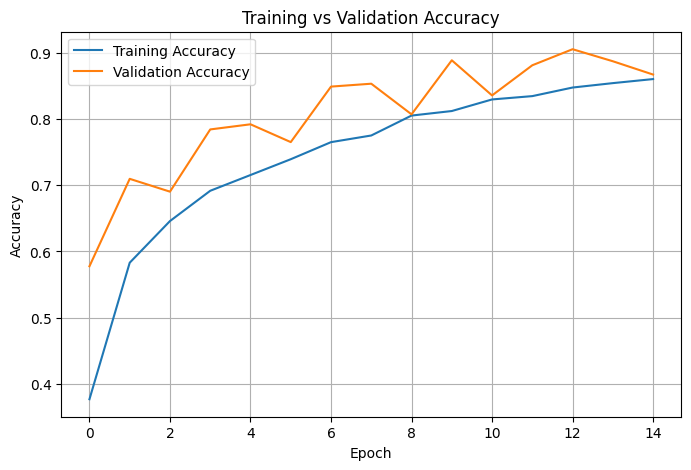

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

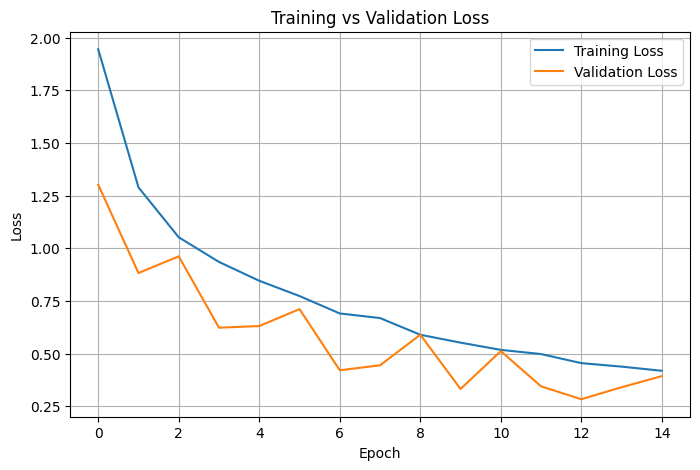

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [28]:
best_epoch = max(
    range(len(history.history['val_accuracy'])),
    key=lambda i: history.history['val_accuracy'][i]
)

best_val_accuracy = history.history['val_accuracy'][best_epoch]

print("Best Epoch:", best_epoch + 1)
print("Best Validation Accuracy:", round(best_val_accuracy * 100, 2), "%")


Best Epoch: 13
Best Validation Accuracy: 90.55 %


In [29]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8672 - loss: 0.3929
Validation Loss: 0.3928595781326294
Validation Accuracy: 0.8672158718109131


In [30]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

Actual labels: (4127,)
Predicted labels: (4127,)


In [31]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.93      0.88      0.90       200
                     Pepper__bell___healthy       0.88      0.99      0.93       302
                      Potato___Early_blight       0.94      0.97      0.96       189
                       Potato___Late_blight       0.96      0.64      0.77       188
                           Potato___healthy       0.94      0.55      0.69        31
                      Tomato_Bacterial_spot       0.98      0.73      0.84       441
                        Tomato_Early_blight       0.48      0.91      0.62       191
                         Tomato_Late_blight       0.83      0.82      0.83       341
                           Tomato_Leaf_Mold       0.89      0.85      0.87       185
                  Tomato_Septoria_leaf_spot       0.91      0.86      0.88       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.88      0.78

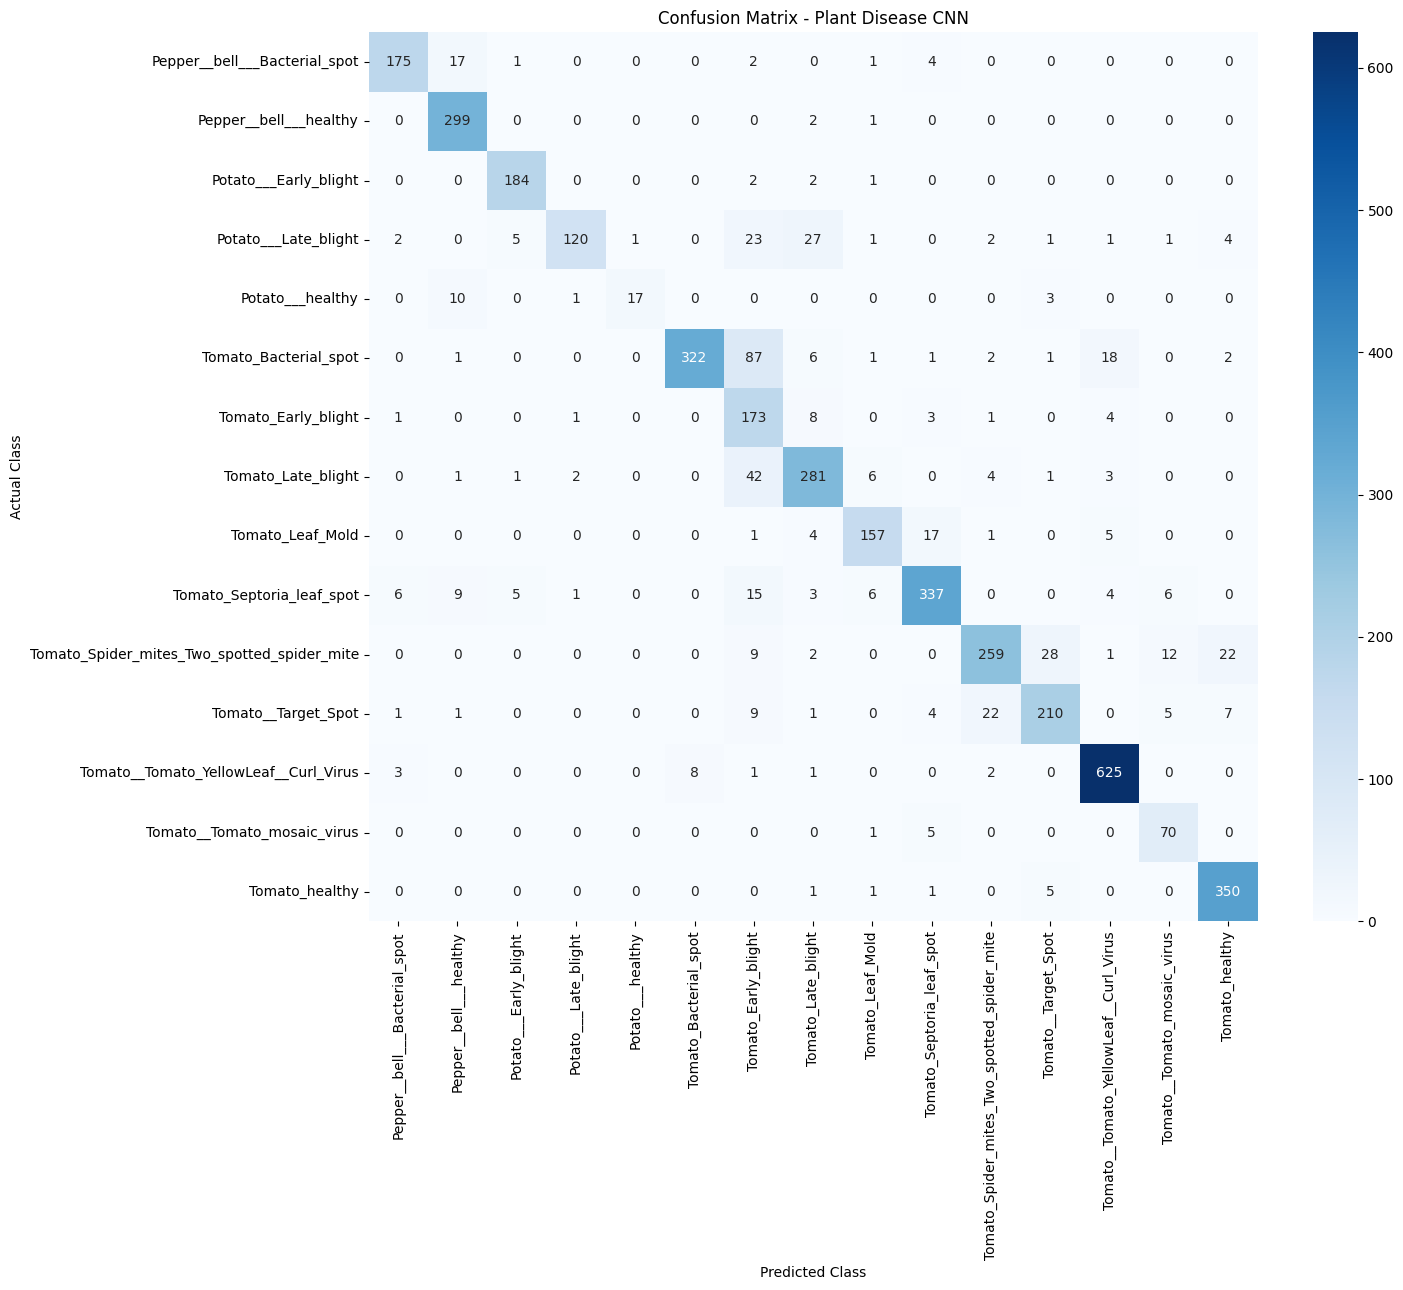

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(15, 13))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Plant Disease CNN")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import classification_report

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

for class_name in class_names:
    print(
        f"{class_name:50s} "
        f"Precision: {report_dict[class_name]['precision']:.3f}  "
        f"Recall: {report_dict[class_name]['recall']:.3f}  "
        f"F1: {report_dict[class_name]['f1-score']:.3f}"
    )

Pepper__bell___Bacterial_spot                      Precision: 0.931  Recall: 0.875  F1: 0.902
Pepper__bell___healthy                             Precision: 0.885  Recall: 0.990  F1: 0.934
Potato___Early_blight                              Precision: 0.939  Recall: 0.974  F1: 0.956
Potato___Late_blight                               Precision: 0.960  Recall: 0.638  F1: 0.767
Potato___healthy                                   Precision: 0.944  Recall: 0.548  F1: 0.694
Tomato_Bacterial_spot                              Precision: 0.976  Recall: 0.730  F1: 0.835
Tomato_Early_blight                                Precision: 0.475  Recall: 0.906  F1: 0.623
Tomato_Late_blight                                 Precision: 0.831  Recall: 0.824  F1: 0.828
Tomato_Leaf_Mold                                   Precision: 0.892  Recall: 0.849  F1: 0.870
Tomato_Septoria_leaf_spot                          Precision: 0.906  Recall: 0.860  F1: 0.882
Tomato_Spider_mites_Two_spotted_spider_mite        Precision

In [34]:
from google.colab import files
uploaded = files.upload()

Saving test image.jpg to test image (1).jpg


In [37]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

In [38]:
image_path = list(uploaded.keys())[0]

img = load_img(
    image_path,
    target_size=(128, 128)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Predicted class: Tomato_Bacterial_spot
Confidence: 86.32 %


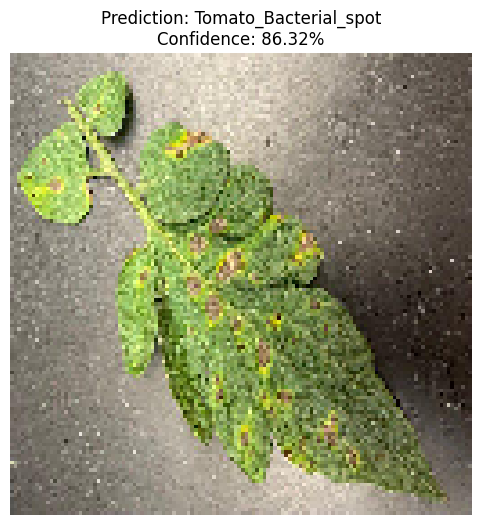

In [39]:
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()